In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mutual_info_score

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import FunctionTransformer
from category_encoders import MEstimateEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    brier_score_loss,
    precision_score,
    recall_score,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    f1_score
)
from sklearn.calibration import calibration_curve
from sklearn.feature_selection import RFE
from sklearn.metrics import fbeta_score

import eli5
from sklearn.inspection import permutation_importance as sklearn_permutation_importance
import shap

# Get data

In [3]:
origin_2024_Q1_df = pd.read_csv("historical_data_2024/historical_data_2024Q1/orig_2024Q1.txt",sep="|",header=None)
perform_2024_q1_df = pd.read_csv("historical_data_2024/historical_data_2024Q1/perf_2024Q1.txt",sep="|",header=None)

/var/folders/t2/_pywhmm106s1vjr8m0jr12hm0000gn/T/ipykernel_56607/2225058536.py:2: DtypeWarning: Columns (0: 3, 1: 7, 2: 23, 3: 24, 4: 28) have mixed types. Specify dtype option on import or set low_memory=False.
  perform_2024_q1_df = pd.read_csv("historical_data_2024/historical_data_2024Q1/perf_2024Q1.txt",sep="|",header=None)


In [4]:
origination_columns = [
    "classic_fico",
    "first_payment_date",
    "first_time_homebuyer_indicator",
    "maturity_date",
    "msa_or_metropolitan_division",
    "mi_percentage",
    "number_of_units",
    "occupancy_status",
    "original_cltv",
    "original_dti",
    "original_upb",
    "original_ltv",
    "original_interest_rate",
    "channel",
    "prepayment_penalty_indicator",
    "amortization_type",
    "property_state",
    "property_type",
    "postal_code",
    "loan_identifier",
    "loan_purpose",
    "original_loan_term",
    "number_of_borrowers",
    "seller_name",
    "super_conforming_flag",
    "pre_harp_loan_sequence_number",
    "special_eligibility_program",
    "harp_indicator",
    "property_valuation_method",
    "interest_only_indicator",
    "vantagescore_4_0"
]
performance_columns = [
    "loan_identifier",
    "period",
    "current_actual_upb",
    "current_loan_delinquency_status",
    "loan_age",
    "remaining_months_to_legal_maturity",
    "underwriting_defect_and_major_servicing_defect_settlement_date",
    "modification_flag",
    "zero_balance_code",
    "zero_balance_effective_date",
    "current_interest_rate",
    "current_non_interest_bearing_upb",
    "due_date_of_last_paid_installment",
    "mi_recoveries",
    "net_sales_proceeds",
    "non_mi_recoveries",
    "total_expenses",
    "legal_costs",
    "maintenance_and_preservation_costs",
    "taxes_and_insurance",
    "miscellaneous_expenses",
    "actual_loss",
    "cumulative_modification_costs",
    "interest_rate_step_indicator",
    "payment_deferral_flag",
    "estimated_ltv",
    "zero_balance_removal_upb",
    "delinquent_accrued_interest",
    "delinquency_due_to_disaster",
    "borrower_assistance_plan",
    "current_period_modification_costs",
    "current_interest_bearing_upb",
    "mortgage_insurance_cancellation_indicator",
    "servicer_name",
    "bankruptcy_cramdown_costs"
]

assert len(performance_columns) == 35

origin_2024_Q1_df.columns=origination_columns
perform_2024_q1_df.columns=performance_columns




# Preliminary

## Target table creation

In [5]:
origin_2024_Q1 = origin_2024_Q1_df.copy()
perform_2024_q1 = perform_2024_q1_df.copy()

In [6]:
assert origin_2024_Q1["loan_identifier"].is_unique

performance_with_age = perform_2024_q1.merge(
    origin_2024_Q1[
        ["loan_identifier", "first_payment_date"]
    ],
    on="loan_identifier",
    how="left",
    validate="many_to_one"
)

performance_with_age["first_payment_date_parsed"] = pd.to_datetime(
    performance_with_age["first_payment_date"].astype("string"),
    format="%Y%m",
    errors="coerce"
)

performance_with_age["period_parsed"] = pd.to_datetime(
    performance_with_age["period"].astype("string"),
    format="%Y%m",
    errors="coerce"
)

performance_with_age["original_loan_age"] = (
    (
        performance_with_age["period_parsed"].dt.year
        - performance_with_age["first_payment_date_parsed"].dt.year
    ) * 12
    +
    (
        performance_with_age["period_parsed"].dt.month
        - performance_with_age["first_payment_date_parsed"].dt.month
    )
    + 1
)

target_df = (
    performance_with_age.loc[
        performance_with_age["original_loan_age"].eq(20),
        [
            "loan_identifier",
            "current_loan_delinquency_status"
        ]
    ]
    .rename(
        columns={
            "current_loan_delinquency_status":
                "status_at_month_20"
        }
    )
    .reset_index(drop=True)
)

status_column = "status_at_month_20"

target_df[status_column] = (
    target_df[status_column]
    .astype("string")
    .str.strip()
    .str.upper()
)

numeric_mask = target_df[status_column].str.fullmatch(
    r"\d+"
)

target_df.loc[numeric_mask, status_column] = (
    target_df.loc[numeric_mask, status_column]
    .str.zfill(2)
)

status_numeric = pd.to_numeric(
    target_df[status_column],
    errors="coerce"
)

target_df["target_90plus"] = (
    status_numeric.ge(3)
    | target_df[status_column].eq("RA")
).astype("Int8")
unavailable_status = (
    target_df[status_column].isna()
    | target_df[status_column].eq("XX")
)

target_df.loc[
    unavailable_status,
    "target_90plus"
] = pd.NA

pd.crosstab(
    target_df[status_column],
    target_df["target_90plus"],
    dropna=False
)

target_df = target_df[
    ["loan_identifier", "target_90plus"]
].copy()

model_df = origin_2024_Q1.merge(
    target_df,
    on="loan_identifier",
    how="inner",
    validate="one_to_one"
)


## Data Cleaning

In [7]:
number_of_borrowers_map={
    3:2,
    4:2,
    5:2,
    6:2,
    7:2,
    8:2,
    9:2,
    10:2
}
evaluation_method_map={
    1:" appraisal waiver (ACE)",
    2:"appraisal",
    3:"other",
    4:"ACE_PDR"
}

In [8]:
model_df["classic_fico"] = model_df["classic_fico"].replace(to_replace=9999 , value=np.nan)
model_df["first_time_homebuyer_indicator"] = model_df["first_time_homebuyer_indicator"].replace(to_replace=9 , value=np.nan)
model_df["first_time_homebuyer_indicator"] = (model_df["first_time_homebuyer_indicator"] == "Y").astype(int)
model_df["mi_percentage"] = model_df["mi_percentage"].replace(to_replace=999 , value=np.nan)
model_df["number_of_units"] = model_df["number_of_units"].replace(to_replace=99 , value=np.nan)
model_df["occupancy_status"] = model_df["occupancy_status"].replace(to_replace=9 , value=np.nan)
model_df["original_cltv"] = model_df["original_cltv"].replace(to_replace=999 , value=np.nan)
model_df["original_dti"] = model_df["original_dti"].replace(to_replace=999 , value=np.nan)
model_df["original_ltv"] = model_df["original_ltv"].replace(to_replace=999 , value=np.nan)
model_df["channel"] = model_df["channel"].replace(to_replace=9 , value=np.nan)
model_df["prepayment_penalty_indicator"] = (model_df["prepayment_penalty_indicator"] == "Y").astype(int)
model_df["property_type"] = model_df["property_type"].replace(to_replace=99 , value=np.nan)
model_df["postal_code"] = model_df["postal_code"].replace(to_replace=000 , value=np.nan)
model_df["loan_purpose"] = model_df["loan_purpose"].replace(to_replace=9 , value=np.nan)
model_df["number_of_borrowers"] = model_df["number_of_borrowers"].replace(to_replace=99 , value=np.nan)
model_df["number_of_borrowers"] = model_df["number_of_borrowers"].replace(number_of_borrowers_map)
model_df["super_conforming_flag"] = (model_df["super_conforming_flag"] == "Y").astype(int)
model_df["special_eligibility_program"] = model_df["special_eligibility_program"].fillna("NONE_OR_NA")
model_df["property_valuation_method"] = model_df["property_valuation_method"].replace(to_replace=7 , value=np.nan)
model_df["property_valuation_method"] = model_df["property_valuation_method"].replace(evaluation_method_map)
first_payment_date= pd.to_datetime(
    model_df["first_payment_date"].astype("string"),
    format = "%Y%m",
    errors="coerce"
)
model_df["first_payment_month"]=first_payment_date.dt.month
maturity_date = pd.to_datetime(
    model_df["maturity_date"].astype("string"),
    format="%Y%m",
    errors="coerce"
)
model_df["effective_loan_duration"]= ((maturity_date.dt.year - first_payment_date.dt.year)*12+(maturity_date.dt.month-first_payment_date.dt.month))

del model_df["loan_identifier"]
del model_df["pre_harp_loan_sequence_number"]
del model_df["harp_indicator"]
del model_df["interest_only_indicator"]
del model_df["vantagescore_4_0"]
del model_df["first_payment_date"]
del model_df["maturity_date"]




In [9]:
model_df

,classic_fico,first_time_homebuyer_indicator,msa_or_metropolitan_division,mi_percentage,number_of_units,occupancy_status,original_cltv,original_dti,original_upb,original_ltv,...,loan_purpose,original_loan_term,number_of_borrowers,seller_name,super_conforming_flag,special_eligibility_program,property_valuation_method,target_90plus,first_payment_month,effective_loan_duration
0,747.0,0,NaN,0,1,P,67,26.0,82000,67,...,P,360,1,OTHER,0,NONE_OR_NA,appraisal,0,3,359
1,710.0,0,NaN,0,1,P,55,36.0,295000,55,...,C,360,1,OTHER,0,NONE_OR_NA,appraisal,0,5,359
2,659.0,0,NaN,0,1,P,68,32.0,305000,68,...,P,360,2,OTHER,0,NONE_OR_NA,appraisal,0,3,359
3,784.0,0,46540.0,0,1,P,76,50.0,125000,76,...,C,360,1,OTHER,0,NONE_OR_NA,appraisal,0,3,359
4,775.0,0,46540.0,0,2,I,70,15.0,154000,70,...,C,360,2,OTHER,0,NONE_OR_NA,appraisal,0,3,359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182997,764.0,0,26420.0,0,1,I,80,42.0,112000,80,...,P,180,2,OTHER,0,NONE_OR_NA,appraisal,0,5,179
182998,742.0,0,26420.0,0,1,P,80,34.0,436000,80,...,P,360,1,OTHER,0,NONE_OR_NA,appraisal,0,4,359
182999,698.0,1,35614.0,35,1,P,102,50.0,451000,97,...,P,360,2,OTHER,0,F,appraisal,0,4,359
183000,728.0,1,15804.0,30,1,P,100,24.0,219000,95,...,P,360,2,OTHER,0,F,appraisal,0,3,359


## Column division 

In [10]:
columns=[
    'classic_fico', 'first_time_homebuyer_indicator',
       'msa_or_metropolitan_division', 'mi_percentage', 'number_of_units',
       'occupancy_status', 'original_cltv', 'original_dti', 'original_upb',
       'original_ltv', 'original_interest_rate', 'channel',
       'prepayment_penalty_indicator', 'amortization_type', 'property_state',
       'property_type', 'postal_code', 'loan_purpose', 'original_loan_term',
       'number_of_borrowers', 'seller_name', 'super_conforming_flag',
       'special_eligibility_program', 'property_valuation_method',
       'first_payment_month', "effective_loan_duration"
]
all_columns = columns + ["target_90plus"]


numerical_columns =['classic_fico','mi_percentage','original_cltv', 'original_dti', 'original_upb',
       'original_ltv', 'original_interest_rate',]

categorical_columns=['first_time_homebuyer_indicator','msa_or_metropolitan_division','number_of_units','occupancy_status','channel',
       'prepayment_penalty_indicator', 'amortization_type', 'property_state',
       'property_type','postal_code','loan_purpose', 'original_loan_term',
       'number_of_borrowers', 'seller_name', 'super_conforming_flag','special_eligibility_program', 'property_valuation_method',
               'first_payment_month', "effective_loan_duration"]

# Encoding methods

one_hot_encoding_columns= [ "first_time_homebuyer_indicator","number_of_units","occupancy_status","channel","amortization_type","prepayment_penalty_indicator","property_type"
                           ,"loan_purpose","number_of_borrowers","super_conforming_flag","special_eligibility_program","property_valuation_method","first_payment_month"]
target_encoding_columns=["msa_or_metropolitan_division","property_state","postal_code",
                            "original_loan_term","seller_name","effective_loan_duration"]



In [11]:
model_df[categorical_columns]=model_df[categorical_columns].astype("string")
model_df[numerical_columns]=model_df[numerical_columns].astype("float64")


# EDA

In [11]:
model_df_eda = model_df.copy()
origin_2024_Q1_eda= origin_2024_Q1.copy()

## Basic exploration

In [12]:
n_loans = origin_2024_Q1.shape[0]
print(f"Number of original loans : {n_loans}")
print(f"Number of lians with 20 month target : {model_df.shape[0]}")
print(f"Number of excluded loans : {n_loans-model_df.shape[0]} , that is {round(((n_loans-model_df.shape[0])/n_loans)*100,3)} %")

Number of original loans : 215009
Number of lians with 20 month target : 183002
Number of excluded loans : 32007 , that is 14.886 %


In [13]:
defective_df =  model_df.target_90plus.value_counts(dropna=False)
global_defective = model_df.target_90plus.mean() 

print(f"Non defective loans in 20 months time with a defectivness of 90+ days : {defective_df.loc[0]} \nDefective loans in 20 months time with a defectivness of 90+ days : {defective_df.iloc[1]}")
print(f"\n\nGlobal defective rate : {round(global_defective,5)} %")
print("\nThe data id highly unbalanced , this have to be taken into consideration for evaluation")

Non defective loans in 20 months time with a defectivness of 90+ days : 181722 
Defective loans in 20 months time with a defectivness of 90+ days : 1280


Global defective rate : 0.00699 %

The data id highly unbalanced , this have to be taken into consideration for evaluation


## Analize target coverage

In [14]:
origin_2024_Q1_eda["has_month_20_target"]=(
    origin_2024_Q1_eda["loan_identifier"].isin(target_df["loan_identifier"]).astype("int8")
)

In [15]:
# What happend to those not chosen loans : evaluating bias

excluded_loans_identifier = origin_2024_Q1_eda.loc[origin_2024_Q1_eda["has_month_20_target"].eq(0),"loan_identifier"]
performance_excluded_loans = perform_2024_q1.loc[perform_2024_q1["loan_identifier"].isin(excluded_loans_identifier)].copy()

performance_excluded_loans = performance_excluded_loans.sort_values(["loan_identifier","period"]).groupby("loan_identifier").tail(1)

In [16]:
zero_balance_code_df = performance_excluded_loans["zero_balance_code"].copy()
zero_balance_map = {
    1:"voluntary payoff or maturity",
    96:"defect before event",
    2:"third-party sale",
    9:"REOdisposition",
    16:"reperforming-loan sale",
    3:"short sale/charge-off",
    15:"whole-loan sale"
}

zero_balance_code_df = zero_balance_code_df.map(zero_balance_map).fillna("Missing")
zero_balance_code_distribution = zero_balance_code_df.value_counts()
zero_balance_code_distribution

zero_balance_code
voluntary payoff or maturity    30942
defect before event               854
Missing                           185
third-party sale                   13
REOdisposition                      8
short sale/charge-off               4
reperforming-loan sale              1
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='zero_balance_code'>

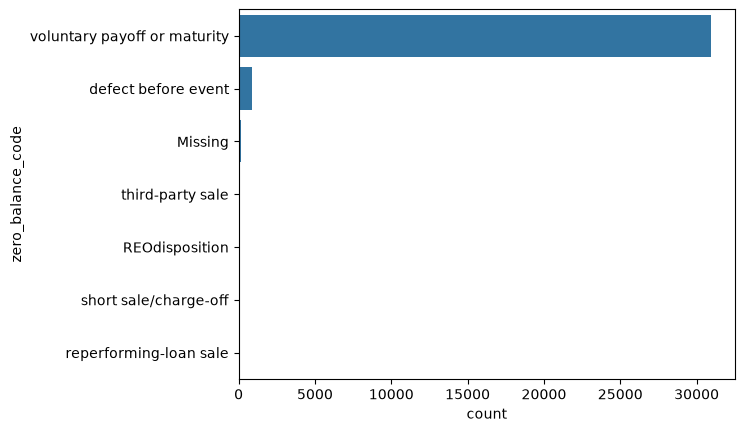

In [17]:
#sns.barplot(zero_balance_code_distribution.drop(index=["Missing"]),orient="h")
sns.barplot(zero_balance_code_distribution,orient="h")

In [18]:
default_events = [
    "third-party sale",
    "REOdisposition",
    "short sale/charge-off"
]
non_default_events = [
    "voluntary payoff or maturity",
    "reperforming-loan sale"
]
uncertain_events = [
    "defect before event",  
    "Missing"               
]

defaults = zero_balance_code_distribution.loc[default_events].sum()
non_default = zero_balance_code_distribution.loc[non_default_events].sum()
uncertain = zero_balance_code_distribution.loc[uncertain_events].sum()
total = zero_balance_code_df.shape[0]

print(f"Non-default loans are : {non_default} and are the {round(non_default/total,3)} % of non cosidered loans")
print(f"Uncertain loans are : {uncertain} and are the {round(uncertain/total,3)} % of non cosidered loans")
print(f"\n\nDefault loans are : {defaults} and are the {round(defaults/total,3)} % of non cosidered loans")
print(f"This loans are {round(defaults/n_loans,4)} % of the total loans")
print("The number of not considered default is negligible , we will continue with our data ")


Non-default loans are : 30943 and are the 0.967 % of non cosidered loans
Uncertain loans are : 1039 and are the 0.032 % of non cosidered loans


Default loans are : 25 and are the 0.001 % of non cosidered loans
This loans are 0.0001 % of the total loans
The number of not considered default is negligible , we will continue with our data 


In [19]:
print("There is no significant differenc in this features considered")
origin_2024_Q1_eda.groupby("has_month_20_target")[["classic_fico","original_dti","original_ltv","original_interest_rate"]].agg(["mean","std"]).T


There is no significant differenc in this features considered


has_month_20_target                   0           1
classic_fico           mean  758.880839  753.069322
                       std   191.824179  146.906238
original_dti           mean   37.871309   37.990301
                       std     9.576747   10.046357
original_ltv           mean   70.839223   75.947962
                       std    20.675568   19.183611
original_interest_rate mean    6.920193    6.703909
                       std     0.544620    0.533939

## Numerical and categorical risk

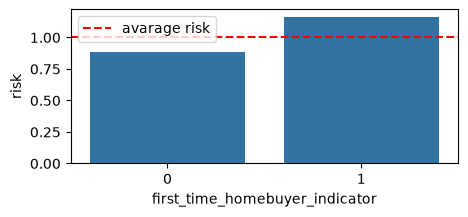

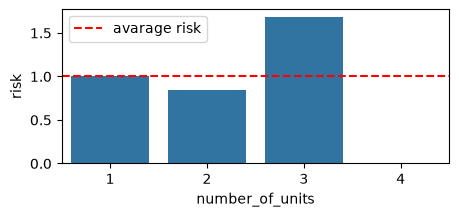

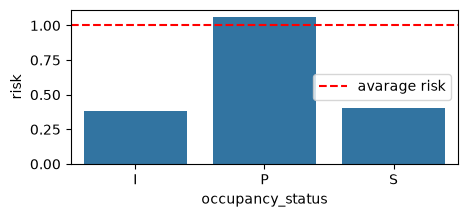

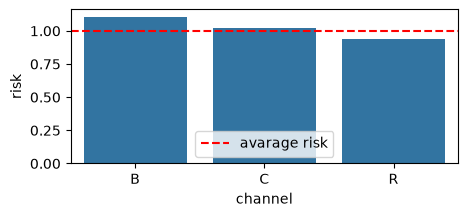

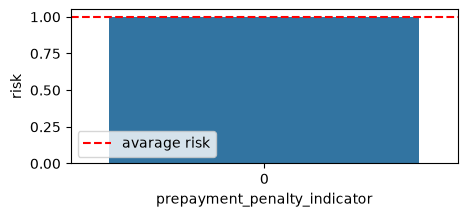

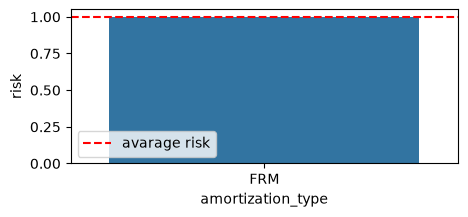

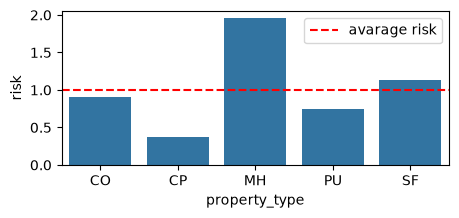

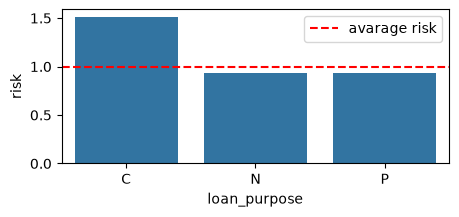

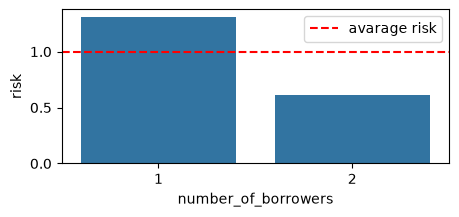

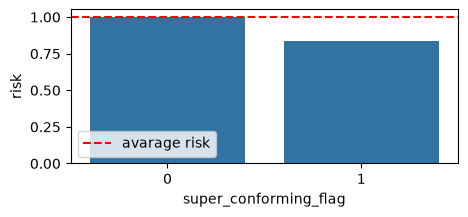

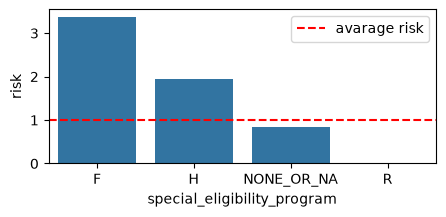

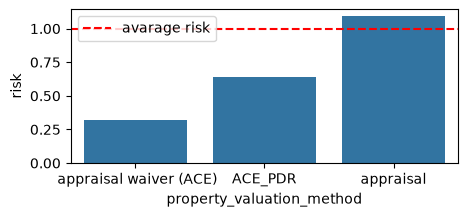

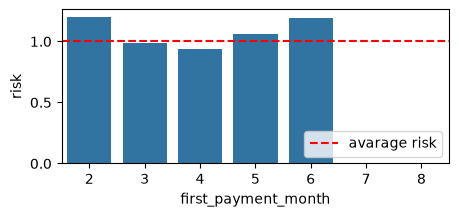

In [20]:
categorical_columns_eda = [col for col in categorical_columns if model_df_eda[col].nunique() <= 10]
for col in categorical_columns_eda:
    df=model_df.groupby(col).target_90plus.agg(["mean","count"])
    df["risk"]=df["mean"]/global_defective

    fig ,ax = plt.subplots(figsize=(5,2))
    sns.barplot(data = df , x=df.index,y=df.risk,ax=ax)
    ax.axhline(y=1,color="red",linestyle="--",label="avarage risk")
    ax.legend()


    


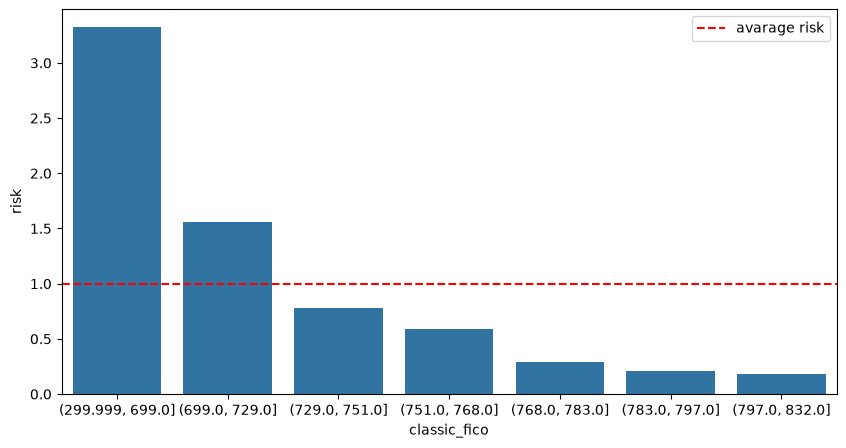

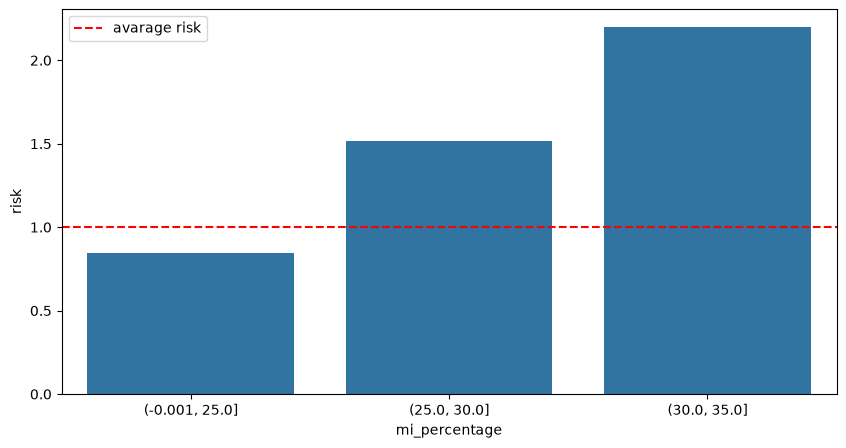

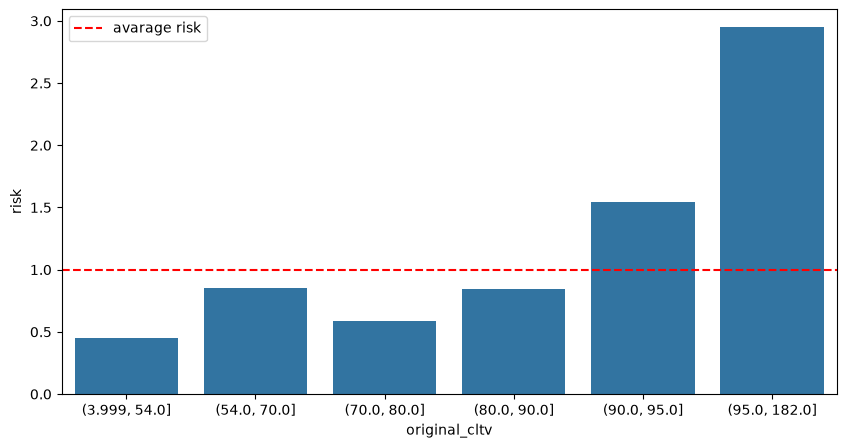

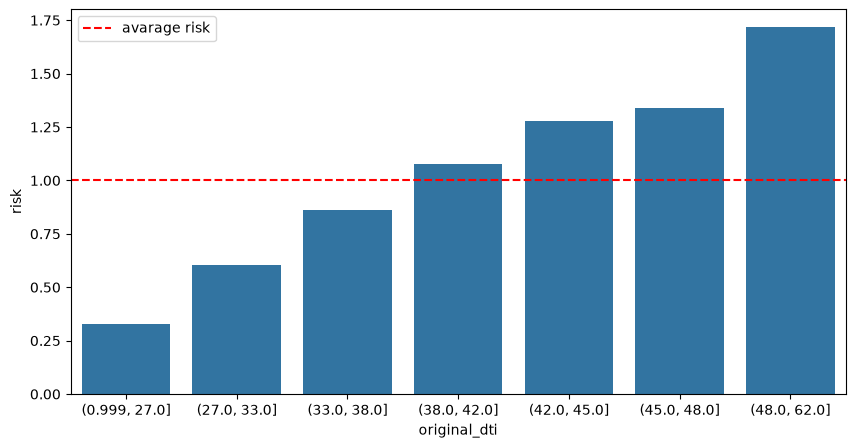

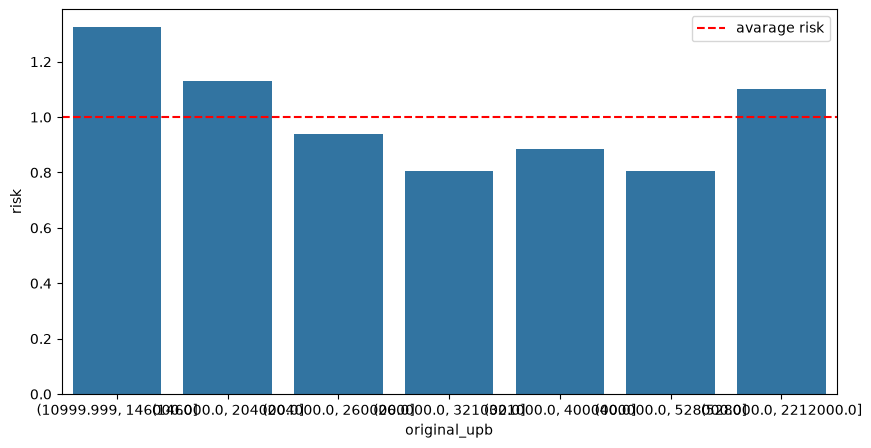

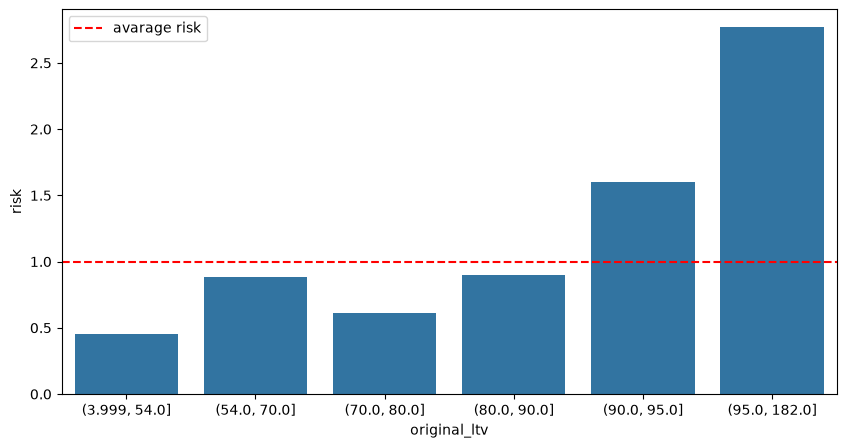

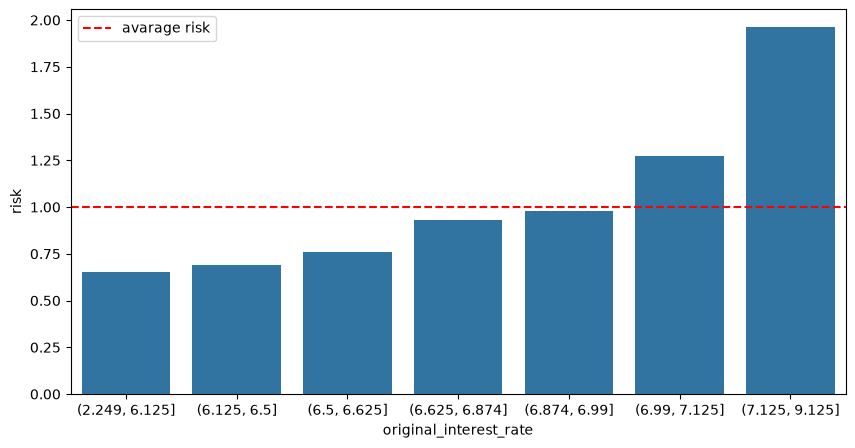

In [21]:

for col in numerical_columns:
    df = model_df[[col,"target_90plus"]].dropna().copy()
    df["bin"]= pd.qcut(
        model_df[col],
        q=7,
        duplicates="drop"
    )
    del df[col]
    df = df.groupby("bin").mean()
    df["risk"]=df/global_defective

    fig ,ax = plt.subplots(figsize=(10,5))
    sns.barplot(data=df,x=df.index , y=df.risk,ax=ax)
    ax.axhline(y=1,color="red",linestyle="--",label="avarage risk")
    ax.legend()
    plt.xlabel(col)
    

## Missing value risk

this feature sees to have a slightly higher risk compard to default , we will consider that


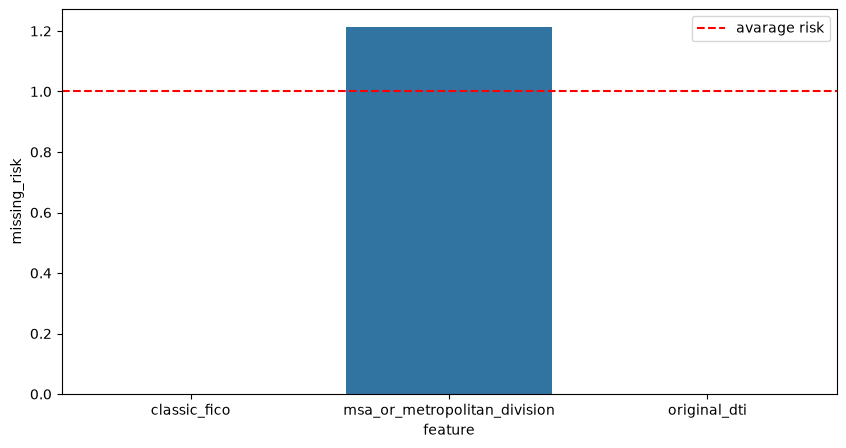

In [22]:
missing_risk = []
for col in columns:
    score = model_df_eda.iloc[model_df_eda[col].isnull(),:].target_90plus.mean()
    if not pd.isna(score):
        missing_risk.append((col,score/global_defective))

missing_risk_df = pd.DataFrame(missing_risk , columns=["feature","missing_risk"])

fig , ax = plt.subplots(figsize=(10,5))
sns.barplot(data=missing_risk_df,x=missing_risk_df["feature"],y=missing_risk_df["missing_risk"],ax=ax)
ax.axhline(y=1,color="red",linestyle="--",label="avarage risk")
ax.legend()
print("this feature sees to have a slightly higher risk compard to default , we will consider that")


## Mutual info and correlation analisys

<Axes: >

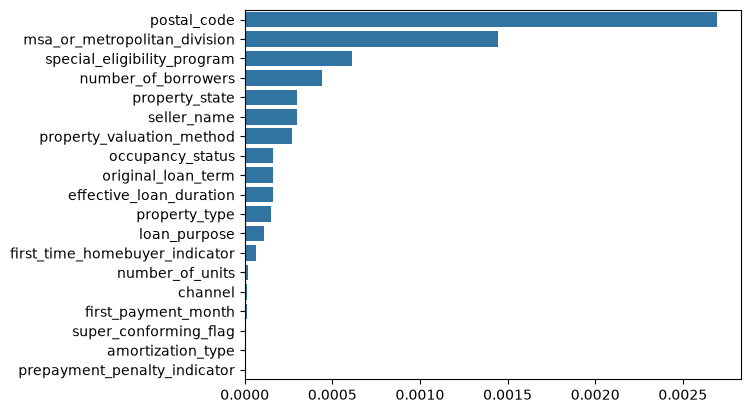

In [23]:
model_df_eda["msa_or_metropolitan_division"] = model_df_eda["msa_or_metropolitan_division"].fillna("NOT available")

def get_mi(column):
    return mutual_info_score(column,model_df_eda.target_90plus)

mi = model_df_eda[categorical_columns].apply(get_mi).sort_values(ascending=False)

sns.barplot(mi,orient="h")

<Axes: >

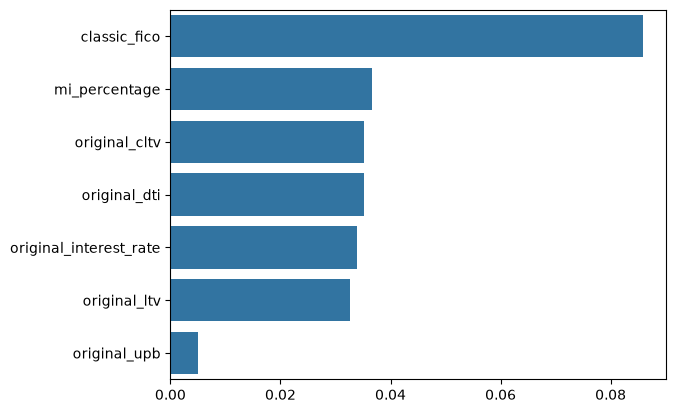

In [24]:
model_df_eda = model_df_eda.fillna(0)

correlation = model_df_eda[numerical_columns].corrwith(model_df_eda.target_90plus).abs().sort_values(ascending=False)

sns.barplot(correlation,orient="h")

## trying to create new features  

<Axes: >

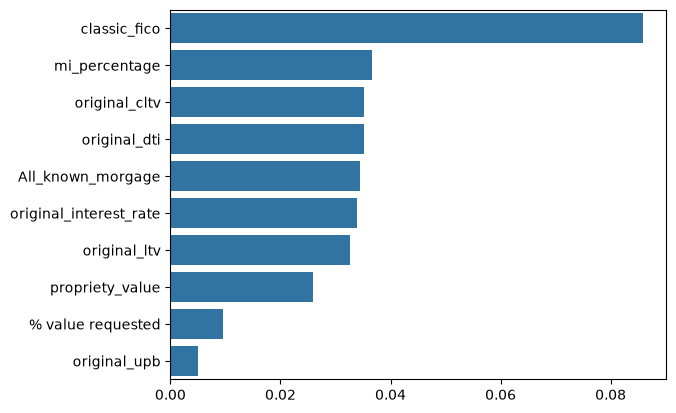

In [25]:
model_df_eda_try = model_df_eda.copy()
'''
def calc(P,r,n):
    numerator = ((1+r)**n)*r
    denominator = ((1+r)**n)-1
    return (numerator/denominator)*P*n

model_df_eda_try["total_amount"]=calc(model_df_eda_try["original_upb"],model_df_eda_try["original_interest_rate"],model_df_eda_try["effective_loan_duration"].astype("float64")).astype("float64")
'''
model_df_eda_try["propriety_value"]=model_df_eda_try["original_ltv"]/model_df_eda_try["original_upb"]
model_df_eda_try["All_known_morgage"]=model_df_eda_try["original_cltv"]*model_df_eda_try["propriety_value"]
model_df_eda_try["% value requested"]=model_df_eda_try["original_upb"]/model_df_eda_try["propriety_value"]

new_columns=["propriety_value","All_known_morgage","% value requested"]
correlation = model_df_eda_try[numerical_columns+new_columns].corrwith(model_df_eda_try.target_90plus).abs().sort_values(ascending=False)

sns.barplot(correlation,orient="h")

In [26]:
model_df_eda_try[numerical_columns].dtypes

classic_fico              float64
mi_percentage             float64
original_cltv             float64
original_dti              float64
original_upb              float64
original_ltv              float64
original_interest_rate    float64
dtype: object

## Correlation between features

<Axes: >

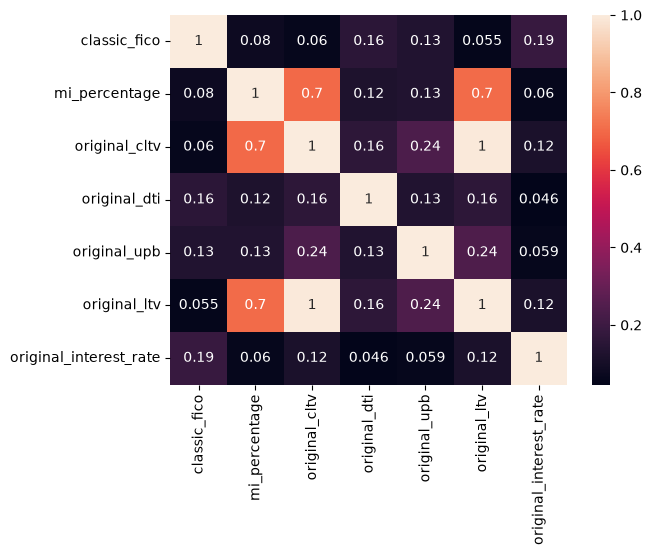

In [27]:
df_corr={}
for col in numerical_columns:
    correlation = model_df_eda[numerical_columns].corrwith(model_df_eda[col]).abs()
    df_corr[col]=correlation
df_corr = pd.DataFrame(df_corr)
sns.heatmap(data = df_corr ,annot=True)

In [28]:


'''
df_mi={}
for col in categorical_columns:
    def get_mi(column):
        return mutual_info_score(column,model_df_eda[col])
    mi = model_df_eda[categorical_columns].apply(get_mi).sort_values(ascending=False)
    df_mi[col]=mi
df_mi = pd.DataFrame(df_mi)
df_mi
'''

'\ndf_mi={}\nfor col in categorical_columns:\n    def get_mi(column):\n        return mutual_info_score(column,model_df_eda[col])\n    mi = model_df_eda[categorical_columns].apply(get_mi).sort_values(ascending=False)\n    df_mi[col]=mi\ndf_mi = pd.DataFrame(df_mi)\ndf_mi\n'

In [29]:
categorical_interesting=["msa_or_metropolitan_division","property_state","postal_code"]
df_mi={}
for col in categorical_interesting:
    def get_mi(column):
        return mutual_info_score(column,model_df_eda[col])
    mi = model_df_eda[categorical_interesting].apply(get_mi).sort_values(ascending=False)
    df_mi[col]=mi
df_mi = pd.DataFrame(df_mi)
df_mi

,msa_or_metropolitan_division,property_state,postal_code
msa_or_metropolitan_division,5.021205,3.028759,4.658776
postal_code,4.658776,3.467003,6.174304
property_state,3.028759,3.467021,3.467003


<Axes: >

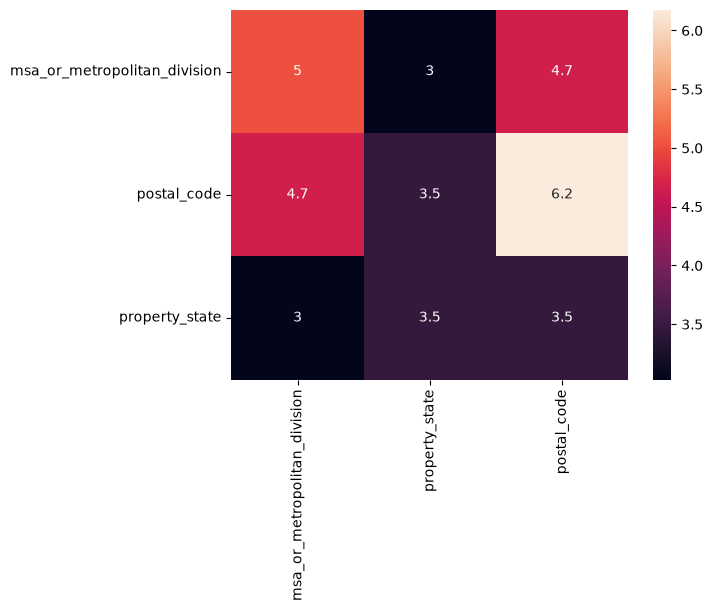

In [30]:
#plt.figure(figsize=(19,19))
sns.heatmap(data=df_mi,annot=True)

# Validation Framework setup

In [12]:
X_full_train , X_test = train_test_split(model_df,random_state=1,test_size=0.2)
X_train , X_val = train_test_split(X_full_train,random_state=1,test_size=0.25)


X_train=X_train.reset_index(drop=True)
X_test=X_test.reset_index(drop=True)
X_val=X_val.reset_index(drop=True)
X_full_train=X_full_train.reset_index(drop=True)

y_train = X_train["target_90plus"].values
y_test = X_test["target_90plus"].values
y_val = X_val["target_90plus"].values
y_full_train = X_full_train["target_90plus"].values

# carefull the target is still in the data sets

# Pipeline

In [13]:
# Feature engineering 
m=5
new_columns= ["position_combined","property_value","All_known_morgage"]

#Create new features
def new_features(X):
    X=X.copy()
    X["property_value"]=X["original_ltv"]/X["original_upb"]
    X["All_known_morgage"]=X["original_cltv"]*X["property_value"]
    X[new_columns[0]]=(
        X["postal_code"].fillna("Missing").astype(str)+
        "-"+
        X["msa_or_metropolitan_division"].fillna("Missing").astype(str)+
        "-"+
        X["property_state"].fillna("Missing").astype(str)
    )
    for column in categorical_columns+numerical_columns+new_columns:
        X[column] = X[column].astype(object)
        X.loc[X[column].isna(), column] = np.nan

    return X
feature_creator = FunctionTransformer(new_features,validate=False)

#numerical transformer
numerical_transformer = IterativeImputer(max_iter=10,random_state=1)

#categorical transformers
one_hot_pipeline = Pipeline(steps=[

    ("imputation",SimpleImputer(strategy="constant",fill_value="missing")),
    ("one_hot_encoding",OneHotEncoder(handle_unknown="ignore"))
])

target_pipeline = Pipeline(steps=[

    ("imputation",SimpleImputer(strategy="constant",fill_value="missing")),
    ("target",TargetEncoder(cv=m,random_state=1,target_type="binary"))

])

#All column transformer

column_transformer=ColumnTransformer(transformers=[
    ("numerical",numerical_transformer,numerical_columns+new_columns[1:2]),
    ("categorical one hot",one_hot_pipeline,one_hot_encoding_columns),
    ("catgorical target",target_pipeline,target_encoding_columns+new_columns)
])



# Model and feature selection

## Model selection

In [ ]:
logistic_regressor= LogisticRegression(random_state=1,max_iter=3000)

decision_tree = DecisionTreeClassifier(random_state=1,max_depth=20)

randomforest =  RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

models=[logistic_regressor,decision_tree,randomforest,xgb_model]



In [ ]:
overall_scores_= {}
calibration_curve_dict={}
for model in models:
    score_df= pd.Series()
    pipeline = Pipeline(steps=[
        ("new features",feature_creator),
        ("impute and encode",column_transformer),
        ("model",model)
    ])
    pipeline.fit(X_train,y_train)

    y_pred = pipeline.predict_proba(X_val)[:,1]

    score_df.loc["ROC-AUC"]=roc_auc_score(y_val,y_pred)
    score_df.loc["Avarage Precision"]=average_precision_score(y_val,y_pred)
    score_df.loc["Brier Score"]=brier_score_loss(y_val,y_pred)
    prob_true , prob_pred = calibration_curve(y_val,y_pred,n_bins=10,strategy="quantile")

    calibration_curve_dict["prob_true %s"%model.__class__.__name__]=prob_true
    calibration_curve_dict["prob_pred %s"%model.__class__.__name__]=prob_pred


    overall_scores_[model.__class__.__name__]=score_df

/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling b

In [ ]:
overall_scores=overall_scores_.copy()
overall_scores = pd.DataFrame(overall_scores)

overall_scores["Baseline"]=[0.5,y_val.mean(),brier_score_loss(y_val,np.random.randint(0,2,len(y_val)))]
col = overall_scores.pop("Baseline")
overall_scores.insert(0,"Baseline",col)
overall_scores.round(4)

,Baseline,LogisticRegression,DecisionTreeClassifier,RandomForestClassifier,XGBClassifier
ROC-AUC,0.5000,0.8353,0.5186,0.8267,0.8444
Avarage Precision,0.0073,0.0384,0.0080,0.0304,0.0417
Brier Score,0.5024,0.0072,0.0156,0.0072,0.0072


In [ ]:

calibration_curve_df = pd.DataFrame({
    key: pd.Series(values)
    for key, values in calibration_curve_dict.items()
})
calibration_curve_df=calibration_curve_df.fillna(0)


In [ ]:
calibration_curve_df

,prob_true LogisticRegression,prob_pred LogisticRegression,prob_true DecisionTreeClassifier,prob_pred DecisionTreeClassifier,prob_true RandomForestClassifier,prob_pred RandomForestClassifier,prob_true XGBClassifier,prob_pred XGBClassifier
0,0.000273,0.000317,0.007069,0.000000,0.000000,0.000603,0.000000,0.000341
1,0.000000,0.000708,0.013253,0.192772,0.000000,0.001088,0.000546,0.000650
2,0.000546,0.001143,0.000000,0.000000,0.000820,0.001551,0.000546,0.000999
3,0.001639,0.001699,0.000000,0.000000,0.001913,0.002116,0.001093,0.001475
4,0.002186,0.002477,0.000000,0.000000,0.002186,0.002977,0.001639,0.002210
5,0.004372,0.003572,0.000000,0.000000,0.003552,0.004271,0.002732,0.003375
6,0.005464,0.005183,0.000000,0.000000,0.007377,0.006025,0.006831,0.005125
7,0.007923,0.007903,0.000000,0.000000,0.007923,0.008418,0.007377,0.008029
8,0.015847,0.013178,0.000000,0.000000,0.015027,0.012784,0.013661,0.013662
9,0.035246,0.033812,0.000000,0.000000,0.034699,0.027288,0.039071,0.033927


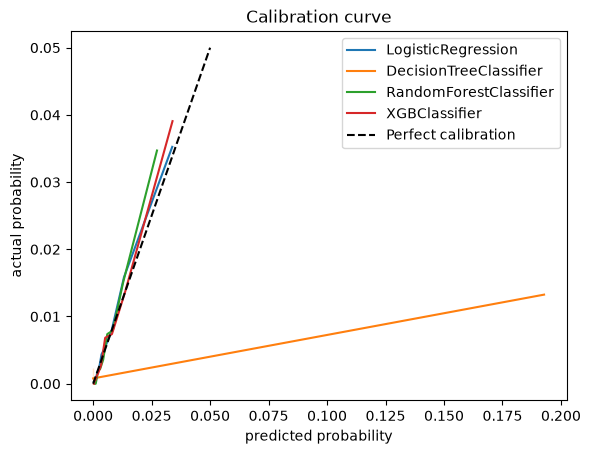

In [ ]:

for modelname in models:
    sns.lineplot(x=calibration_curve_df[f"prob_pred {modelname.__class__.__name__}"],y=calibration_curve_df[f"prob_true {modelname.__class__.__name__}"],label=modelname.__class__.__name__)
plt.xlabel("predicted probability")
plt.ylabel("actual probability")
plt.title("Calibration curve")
plt.plot([0,0.05],[0,0.05],linestyle="--",color="black",label="Perfect calibration")
plt.legend()


## Feature selection

In [ ]:
xgb_model_RFE = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=2,
    
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

n_feature_scores = pd.Series()
for i in range(12,20,1):

    selector = RFE(estimator=xgb_model_RFE,n_features_to_select=i,step=3)

    pipeline = Pipeline(steps=[
            ("new features",feature_creator),
            ("impute and encode",column_transformer),
            ("selector",selector),
            ("model",xgb_model_RFE)

        ])
    pipeline.fit(X_train,y_train)
    y_pred = pipeline.predict_proba(X_val)[:,1]

    n_feature_scores.loc[i]=average_precision_score(y_val,y_pred)

     


/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling b

<Axes: >

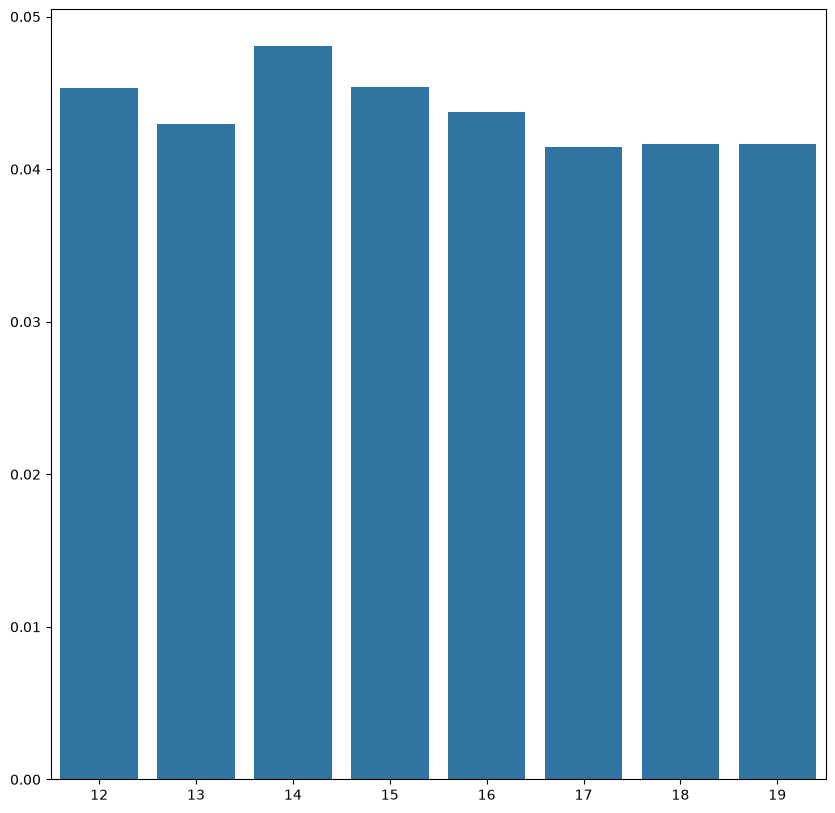

In [ ]:
plt.figure(figsize=(10,10))
sns.barplot(n_feature_scores)


In [ ]:
feature_names = pipeline.named_steps["impute and encode"].get_feature_names_out()
selector= pipeline.named_steps["selector"]
selected_features=feature_names[selector.support_]

In [ ]:
list(selected_features) 

['numerical__classic_fico',
 'numerical__original_cltv',
 'numerical__original_dti',
 'numerical__original_upb',
 'numerical__original_ltv',
 'numerical__original_interest_rate',
 'categorical one hot__loan_purpose_C',
 'categorical one hot__loan_purpose_P',
 'categorical one hot__number_of_borrowers_1',
 'categorical one hot__special_eligibility_program_F',
 'categorical one hot__special_eligibility_program_NONE_OR_NA',
 'categorical one hot__property_valuation_method_ appraisal waiver (ACE)',
 'catgorical target__seller_name',
 'catgorical target__position_combined']

# Model tuning

In [ ]:
tuning_scores=[]
for i in[0.05,0.1,0.2]:
    for j in [1,2,3,4,5]:
        selector_tuned = RFE(estimator=xgb_model_RFE,n_features_to_select=14,step=1)

        xgb_model_tuned = XGBClassifier(
            n_estimators=100,
            learning_rate=i,
            max_depth=j,
            
            eval_metric="auc",
            random_state=42,
            n_jobs=-1
        )

        pipeline_tuned = Pipeline(steps=[
                    ("new features",feature_creator),
                    ("impute and encode",column_transformer),
                    ("selector",selector_tuned),
                    ("model",xgb_model_tuned)

                ])
        pipeline_tuned.fit(X_train,y_train)
        y_pred_tuning = pipeline_tuned.predict_proba(X_val)[:,1]

        tuning_scores.append((i,j,average_precision_score(y_val,y_pred_tuning)))



/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling b

In [ ]:
tuning_scores_ = tuning_scores.copy()
tuning_scores_

[(0.05, 1, 0.036051679717859456),
 (0.05, 2, 0.04106759629413358),
 (0.05, 3, 0.042993525431255585),
 (0.05, 4, 0.0424104697239663),
 (0.05, 5, 0.041981846507415904),
 (0.1, 1, 0.04095656112947954),
 (0.1, 2, 0.04209233106818585),
 (0.1, 3, 0.045806452798345235),
 (0.1, 4, 0.041629970188783824),
 (0.1, 5, 0.040564803233882424),
 (0.2, 1, 0.041672043231413596),
 (0.2, 2, 0.0419813003381589),
 (0.2, 3, 0.04422293865323654),
 (0.2, 4, 0.04004989560293993),
 (0.2, 5, 0.03490149510486182)]

Text(0.5, 1.0, 'Model tuning , 150 rounds')

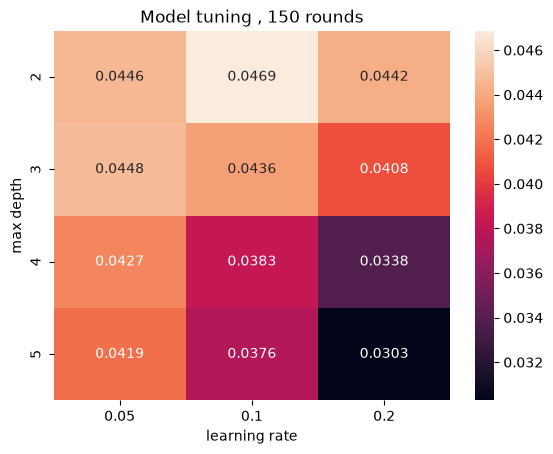

In [ ]:

tuning_scores_ = pd.DataFrame(tuning_scores_, columns=["learning rate","max depth","avarage precision"])
heatmap_data = tuning_scores_.pivot(
    index="max depth",
    columns="learning rate",
    values="avarage precision")
sns.heatmap(data=heatmap_data,annot=True,fmt=".4f")
plt.title("Model tuning , 150 rounds")

Text(0.5, 1.0, 'Model tuning , 200 rounds')

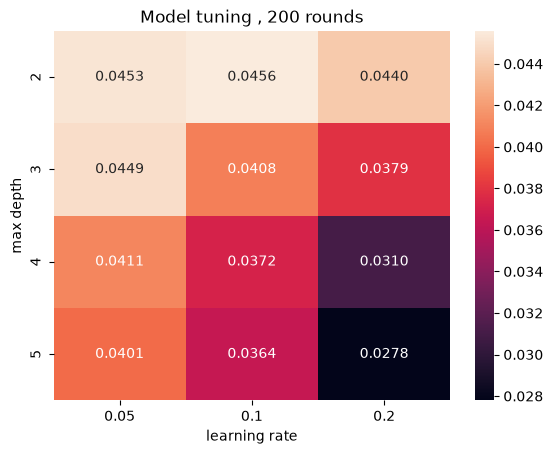

In [ ]:
tuning_scores_ = pd.DataFrame(tuning_scores_, columns=["learning rate","max depth","avarage precision"])
heatmap_data = tuning_scores_.pivot(
    index="max depth",
    columns="learning rate",
    values="avarage precision")
sns.heatmap(data=heatmap_data,annot=True,fmt=".4f")
plt.title("Model tuning , 200 rounds")

Text(0.5, 1.0, 'Model tuning , 100 rounds')

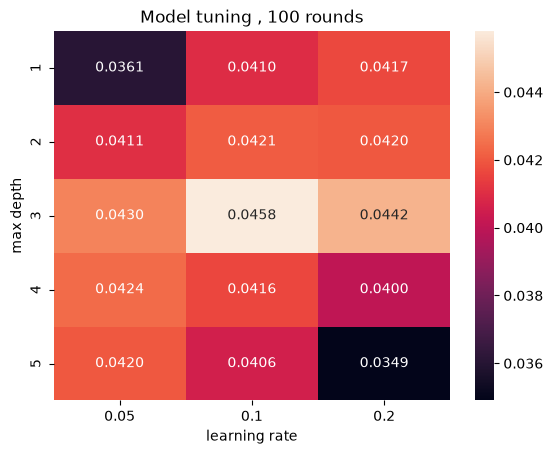

In [ ]:
tuning_scores_ = pd.DataFrame(tuning_scores_, columns=["learning rate","max depth","avarage precision"])
heatmap_data = tuning_scores_.pivot(
    index="max depth",
    columns="learning rate",
    values="avarage precision")
sns.heatmap(data=heatmap_data,annot=True,fmt=".4f")
plt.title("Model tuning , 100 rounds")

Text(0.5, 1.0, 'Model tuning , 75 rounds')

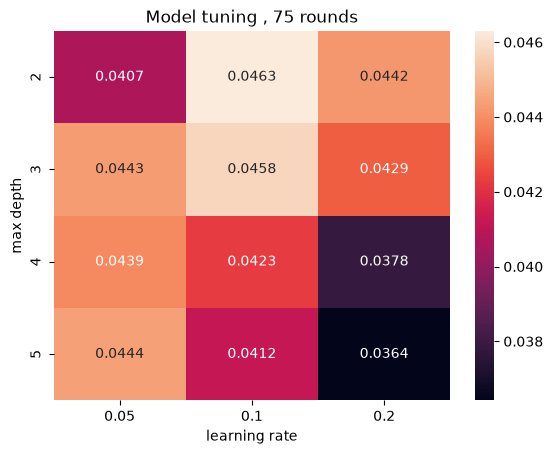

In [ ]:
tuning_scores_ = pd.DataFrame(tuning_scores_, columns=["learning rate","max depth","avarage precision"])
heatmap_data = tuning_scores_.pivot(
    index="max depth",
    columns="learning rate",
    values="avarage precision")
sns.heatmap(data=heatmap_data,annot=True,fmt=".4f")
plt.title("Model tuning , 75 rounds")

# Final model ad threshold selection

## Final model and data

In [ ]:
xgb_model_final = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=2,
    
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

selector_final = RFE(estimator=xgb_model_final,n_features_to_select=16,step=5)
pipeline_final = Pipeline(steps=[
            ("new features",feature_creator),
            ("impute and encode",column_transformer),
            ("selector",selector_final),
            ("model",xgb_model_final)

        ])

pipeline_final.fit(X_full_train,y_full_train)
y_pred = pipeline_final.predict_proba(X_test)[:,1]

/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [15]:
prevalence = y_test.mean()
ap = average_precision_score(y_test, y_pred)

evaluation_metrics = pd.Series({
    "Positive prevalence": prevalence,
    "ROC-AUC": roc_auc_score(y_test, y_pred),
    "Average Precision": ap,
    "AP lift": ap / prevalence,
    "Brier Score": brier_score_loss(y_test, y_pred)
    #"Log Loss": log_loss(y_test, y_pred)
})

evaluation_metrics

Positive prevalence    0.006748
ROC-AUC                0.839618
Average Precision      0.037398
AP lift                5.541702
Brier Score            0.006593
dtype: float64

## Treshold tuning

In [16]:
threshold_dict={}
for t in np.linspace(0,0.19,101):
    prediction = (y_pred >= t).astype(int)
    treshold_series=pd.Series({
    "Precision":precision_score(y_test,prediction),
    "Recall":recall_score(y_test,prediction),
    "F1 score":f1_score(y_test,prediction),
    "f2 score":fbeta_score(y_test,prediction,beta=2),
    "Specificity":recall_score(y_test,prediction,pos_label=0)
    })
    threshold_dict[t]=treshold_series


    

/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/luca/ml-env/lib/python3.12/sit

Text(0.5, 1.0, 'Treshold selection')

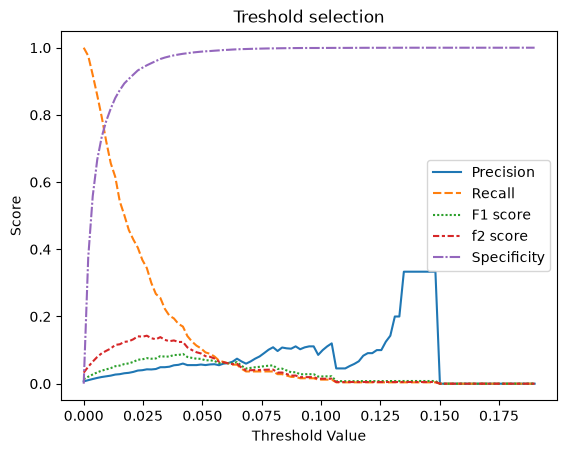

In [17]:
treshold_df = pd.DataFrame(threshold_dict)
sns.lineplot(treshold_df.T)
plt.xlabel("Threshold Value")
plt.ylabel("Score")
plt.title("Treshold selection")

In [18]:
f2_score = treshold_df.loc["f2 score",:].loc[treshold_df.loc["f2 score",:].idxmax()]
threshold = treshold_df.loc["f2 score",:].idxmax()
print(f"The maximum score for f2 score is {f2_score} and we take the threshold of {threshold}")

The maximum score for f2 score is 0.14280913978494625 and we take the threshold of 0.0266


In [19]:
prediction_final = (y_pred >= threshold).astype(int)

In [20]:
accuracy = (prediction_final == y_test).mean()
print(f"The accuracy of the model is {accuracy*100} %")
confusion_matrix_ = confusion_matrix(y_test,prediction_final)

print(f"\nTrue Positive {confusion_matrix_[0][0]}\tFalse positive {confusion_matrix_[0][1]}\n\nFalse negat {confusion_matrix_[1][0]}\t\tTrue negative {confusion_matrix_[1][1]}")

treshold_series_=pd.Series({
    "Precision":precision_score(y_test,prediction_final),
    "Recall":recall_score(y_test,prediction_final),
    "F1 score":f1_score(y_test,prediction_final),
    "f2 score":fbeta_score(y_test,prediction_final,beta=2),
    "Specificity":recall_score(y_test,prediction_final,pos_label=0)
    })
treshold_series_= pd.DataFrame(treshold_series_,columns=["scores"])
treshold_series_

The accuracy of the model is 94.35807764815169 %

True Positive 34451	False positive 1903

False negat 162		True negative 85


,scores
Precision,0.042757
Recall,0.344130
F1 score,0.076063
f2 score,0.142809
Specificity,0.947654


# Model explainability

## Permutation importance

In [24]:
pipeline_final_pi = Pipeline(steps=[
            ("new features",feature_creator),
            ("impute and encode",column_transformer),
            ("model",xgb_model_final)
        ])

socres = sklearn_permutation_importance(
    estimator=pipeline_final,
    X=X_test,
    y=y_test,
    scoring="average_precision",
    n_repeats=10,
    random_state=1,
    n_jobs=-1
)
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
}).sort_values("importance", ascending=False)

importance_df

,feature,importance,std
0,classic_fico,2.355648e-02,1.256084e-03
6,original_cltv,1.345502e-02,1.638305e-03
19,number_of_borrowers,6.665287e-03,2.228817e-03
10,original_interest_rate,3.912064e-03,7.049270e-04
8,original_upb,3.499690e-03,1.528379e-03
20,seller_name,1.009639e-03,1.385626e-03
9,original_ltv,6.979203e-04,8.307119e-04
17,loan_purpose,2.277243e-04,2.089177e-03
15,property_type,0.000000e+00,0.000000e+00
25,first_payment_month,0.000000e+00,0.000000e+00


## SHAP values

In [74]:
shap.initjs()
model=pipeline_final.named_steps["model"]


# row data 
row_to_show = 105
row_data = X_val.iloc[[row_to_show]] 

#background data
background_data= X_full_train.sample(200,random_state=1)

#encode
encoded_data = pipeline_final[:-1].transform(row_data)
background_encoded = pipeline_final[:-1].transform(background_data)

#get names out
feature_names = (pipeline_final.named_steps["impute and encode"].get_feature_names_out())
rfe = pipeline_final.named_steps["selector"]

selected_names=feature_names[rfe.get_support()]

#encode names 

encoded_data = pd.DataFrame(encoded_data,columns=selected_names) 
background_encoded = pd.DataFrame(background_encoded,columns=selected_names) 



def predict_default_probability(X):
    X = pd.DataFrame(X, columns=selected_names)
    return model.predict_proba(X)[:, 1]

masker = shap.maskers.Independent(
    background_encoded,
    max_samples=100
)

explainer = shap.PermutationExplainer(
    predict_default_probability,
    masker,
    feature_names=selected_names.tolist()
)

shap_values = explainer(
    encoded_data,
    max_evals=2 * len(selected_names) + 1
)

shap.initjs()
print(f"Probability predicted is {predict_default_probability(encoded_data)[0]} %")
shap.plots.force(shap_values[0])

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


Probability predicted is 0.004902892746031284 %


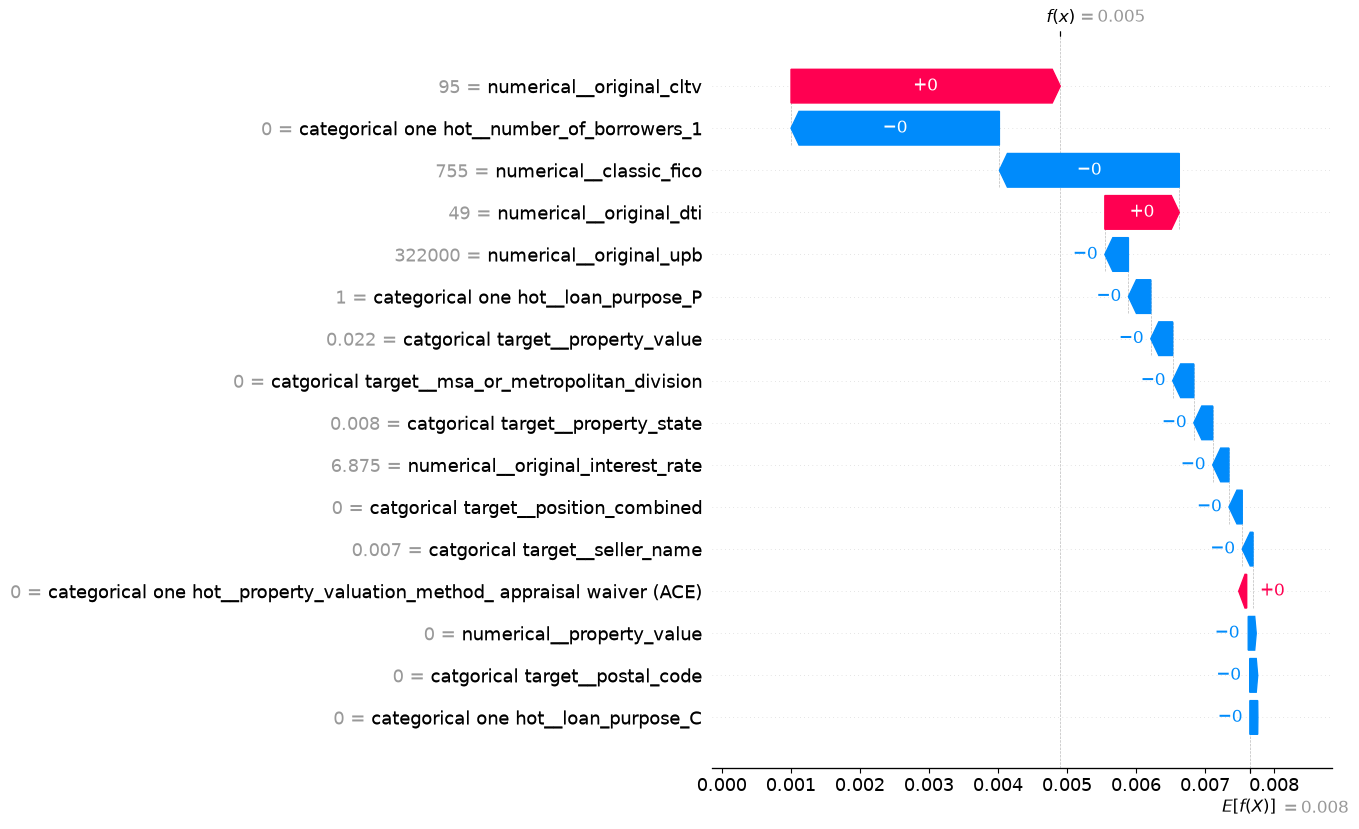

In [72]:
shap.plots.waterfall(shap_values[0],max_display=len(selected_names))